# Generate the noise model for PN2V. The nosie of PAUS image is mainly the poisson.

Firstly we generate the model with the real data. We used the denoised image as the clean image.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
os.chdir('../pn2v/src/pn2v')
import dask.array as da
from scipy.stats import poisson

from core import histNoiseModel

In [2]:
os.chdir('../../..')
path = './data saved/denoised_stamps.npy'

imgs_part_clean = np.load(path)

In [3]:
path = './data saved/cleanstamps_allbandsnew.zarr'

imgs = da.from_zarr(path)
imgs = imgs[:31 * 100]
imgs_part = imgs.compute()

/data/aai/scratch/jchan/miniconda3/envs/denoise/lib/python3.12/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


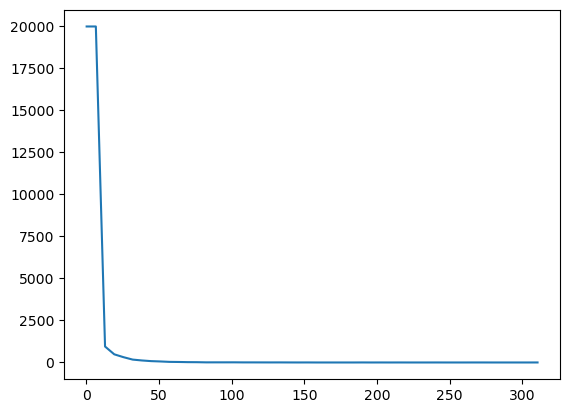

In [4]:
checkSignalHist = np.histogram(imgs_part_clean, bins=50)
plt.plot( checkSignalHist[1][:-1], np.clip(checkSignalHist[0],0,20000))

In [5]:
minVal, maxVal =1, 5
bins = 256

histogramFD = histNoiseModel.createHistogram(bins,minVal,maxVal,imgs_part,imgs_part_clean)

histogramFD=histogramFD[0]

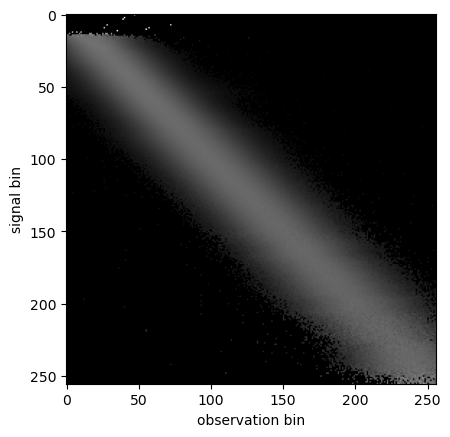

In [6]:
plt.xlabel('observation bin')
plt.ylabel('signal bin')
plt.imshow(histogramFD**0.25, cmap='gray')
plt.show()

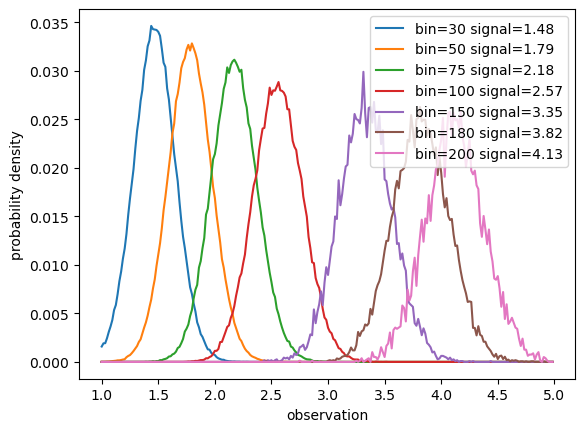

In [7]:
xvals=np.arange(bins)/float(bins)*(maxVal-minVal)+minVal
plt.xlabel('observation')
plt.ylabel('probability density')

index=30
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,histogramFD[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=50
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,histogramFD[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=75
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,histogramFD[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=100
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,histogramFD[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=150
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,histogramFD[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=180
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,histogramFD[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=200
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,histogramFD[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

plt.legend()
plt.show()

In [ ]:
#np.save('./data saved/PAUSnoiseModel.npy', histogramFD)

# Generate the pure poisson noise model  

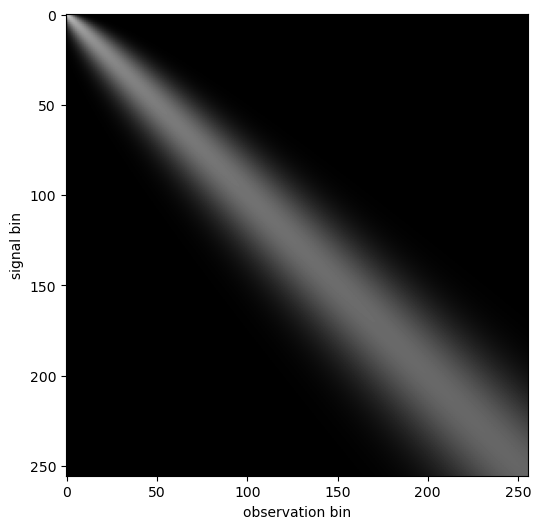

In [8]:
x = np.arange(256)
y = np.arange(256)
X, Y = np.meshgrid(x, y)

smooth_histogram = poisson.pmf(X, mu=Y)

plt.figure(figsize=(6, 6))
plt.xlabel('observation bin')
plt.ylabel('signal bin')

plt.imshow(smooth_histogram**0.25, cmap='gray')
plt.show()

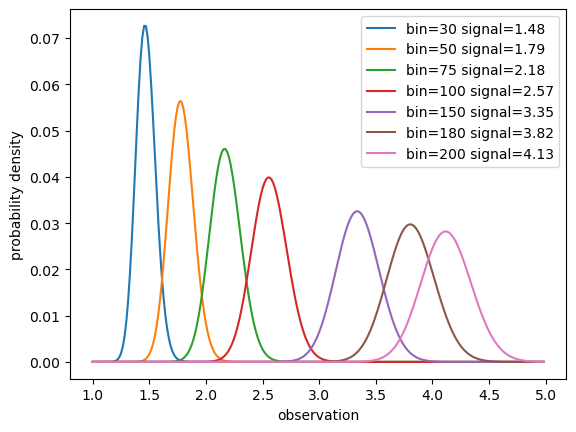

In [10]:
bins = 256
minVal, maxVal =1, 5

xvals=np.arange(bins)/float(bins)*(maxVal-minVal)+minVal
plt.xlabel('observation')
plt.ylabel('probability density')

index=30
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,smooth_histogram[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=50
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,smooth_histogram[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=75
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,smooth_histogram[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=100
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,smooth_histogram[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=150
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,smooth_histogram[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=180
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,smooth_histogram[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

index=200
s=((index+0.5)/float(bins)*(maxVal-minVal)+minVal)
plt.plot(xvals,smooth_histogram[index,:], label='bin='+str(index)+' signal='+str(np.round(s,2)))

plt.legend()
plt.show()

In [ ]:
#np.save('./data saved/PAUSnoiseModel.npy', smooth_histogram)